In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
def outliers_iqr_mod(data, feature, log_scale=False, left=1.5, right=1.5):
    if log_scale:
        x = np.log(data[feature])
    else:
        x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x<lower_bound) | (x > upper_bound)]
    cleaned = data[(x>lower_bound) & (x < upper_bound)]
    return outliers, cleaned

In [35]:
def outliers_z_score_mod(data, feature, log_scale=False, left=3.0, right=3.0):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x > lower_bound) & (x < upper_bound)]
    return outliers, cleaned

In [2]:
diabetes_data = pd.read_csv('data/diabetes_data.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Gender
0,6,98,58,33,190,34.0,0.430,43,0,Female
1,2,112,75,32,0,35.7,0.148,21,0,Female
2,2,108,64,0,0,30.8,0.158,21,0,Female
3,8,107,80,0,0,24.6,0.856,34,0,Female
4,7,136,90,0,0,29.9,0.210,50,0,Female


In [3]:
diabetes_data.shape

(778, 10)

In [4]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               778 non-null    int64  
 1   Glucose                   778 non-null    int64  
 2   BloodPressure             778 non-null    int64  
 3   SkinThickness             778 non-null    int64  
 4   Insulin                   778 non-null    int64  
 5   BMI                       778 non-null    float64
 6   DiabetesPedigreeFunction  778 non-null    float64
 7   Age                       778 non-null    int64  
 8   Outcome                   778 non-null    int64  
 9   Gender                    778 non-null    object 
dtypes: float64(2), int64(7), object(1)
memory usage: 60.9+ KB


In [5]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000
mean,3.848329,120.822622,69.035990,20.457584,79.521851,31.982262,0.470871,33.317481,0.344473
std,3.360782,31.883264,19.432323,15.954452,114.862405,7.853917,0.330669,11.816300,0.475502
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.241500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,27.000000,32.000000,0.370000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,126.750000,36.500000,0.625500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


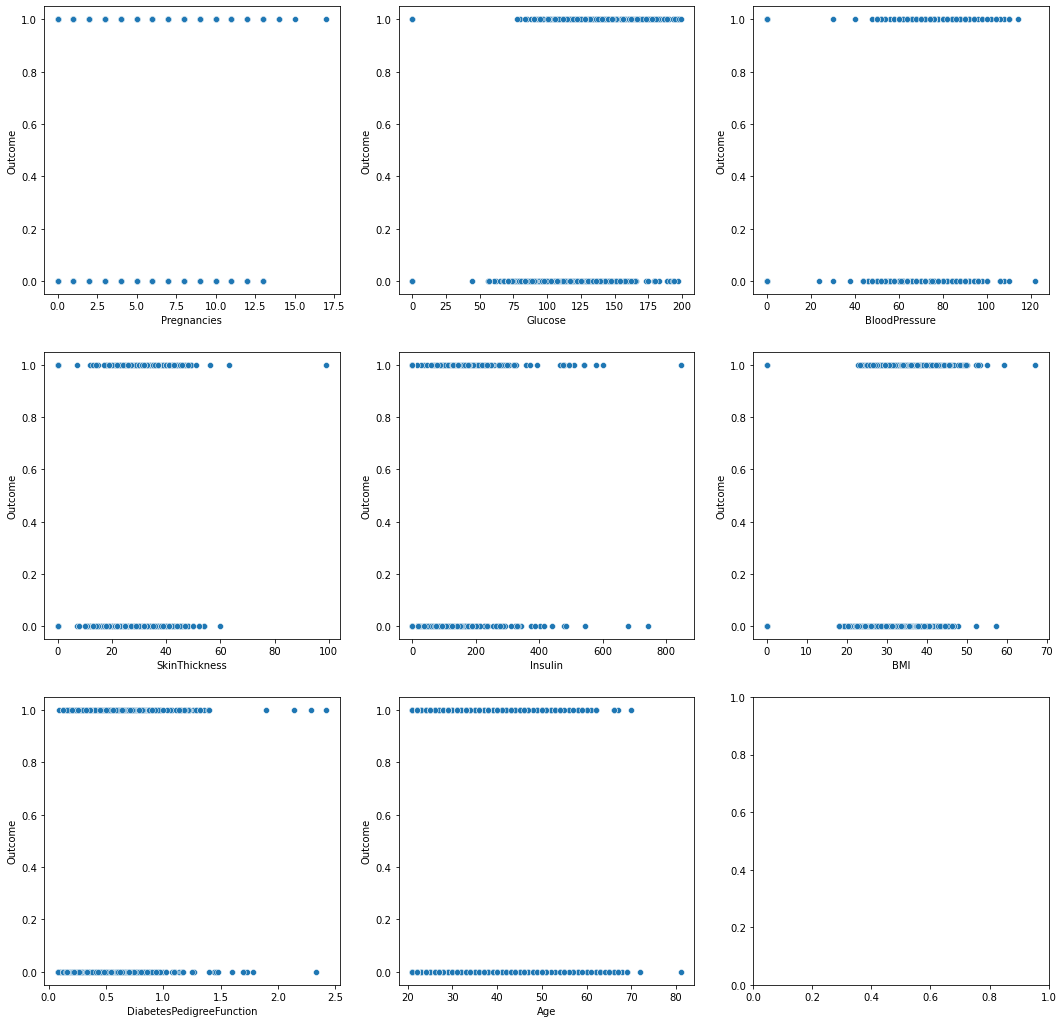

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))

scatterplot_pregnancies = sns.scatterplot(
    data=diabetes_data,
    x='Pregnancies',
    y='Outcome',
    ax=axes[0][0]
)
scatterplot_glucose = sns.scatterplot(
    data=diabetes_data,
    x='Glucose',
    y='Outcome',
    ax=axes[0][1]
)
scatterplot_bloodpressure = sns.scatterplot(
    data=diabetes_data,
    x='BloodPressure',
    y='Outcome',
    ax=axes[0][2]
)
scatterplot_skinthickness = sns.scatterplot(
    data=diabetes_data,
    x='SkinThickness',
    y='Outcome',
    ax=axes[1][0]
)
scatterplot_insulin = sns.scatterplot(
    data=diabetes_data,
    x='Insulin',
    y='Outcome',
    ax=axes[1][1]
)
scatterplot_BMI = sns.scatterplot(
    data=diabetes_data,
    x='BMI',
    y='Outcome',
    ax=axes[1][2]
)
scatterplot_diabetespedigreefunction = sns.scatterplot(
    data=diabetes_data,
    x='DiabetesPedigreeFunction',
    y='Outcome',
    ax=axes[2][0]
)
scatterplot_age = sns.scatterplot(
    data=diabetes_data,
    x='Age',
    y='Outcome',
    ax=axes[2][1]
);

In [7]:
diabetes_data = diabetes_data.drop_duplicates()
diabetes_data.shape[0]

768

In [8]:
#список неинформативных признаков
low_information_cols = [] 

#цикл по всем столбцам
for col in diabetes_data.columns:
    #наибольшая относительная частота в признаке
    top_freq = diabetes_data[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = diabetes_data[col].nunique() / diabetes_data[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.99:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.99:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')

Gender: 100.0% одинаковых значений


In [9]:
diabetes_data = diabetes_data.drop('Gender', axis=1)
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,98,58,33,190,34.0,0.430,43,0
1,2,112,75,32,0,35.7,0.148,21,0
2,2,108,64,0,0,30.8,0.158,21,0
3,8,107,80,0,0,24.6,0.856,34,0
4,7,136,90,0,0,29.9,0.210,50,0


In [10]:
mask = diabetes_data.isnull()
diabetes_data[mask].sum()

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [11]:
col = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_data[col] = diabetes_data[col].replace(0, np.nan)

In [16]:
diabetes_data.isnull().mean().round(2).sort_values(ascending=False)

Insulin                     0.49
SkinThickness               0.30
BloodPressure               0.05
Glucose                     0.01
BMI                         0.01
Pregnancies                 0.00
DiabetesPedigreeFunction    0.00
Age                         0.00
Outcome                     0.00
dtype: float64

In [18]:
thresh = diabetes_data.shape[0] * 0.7
diabetes_data = diabetes_data.dropna(how='any', thresh=thresh, axis=1)
diabetes_data.shape

(768, 8)

In [19]:
thresh = diabetes_data.shape[1] - 2
diabetes_data = diabetes_data.dropna(how='any', thresh=thresh, axis=0)
diabetes_data.shape

(761, 8)

In [20]:
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,98.0,58.0,33.0,34.0,0.430,43,0
1,2,112.0,75.0,32.0,35.7,0.148,21,0
2,2,108.0,64.0,NaN,30.8,0.158,21,0
3,8,107.0,80.0,NaN,24.6,0.856,34,0
4,7,136.0,90.0,NaN,29.9,0.210,50,0


In [26]:
values = {
    'Glucose': diabetes_data['Glucose'].median(),
    'BloodPressure': diabetes_data['BloodPressure'].median(),
    'SkinThickness': diabetes_data['SkinThickness'].median(),  
    'BMI': diabetes_data['BMI'].median()   
}
diabetes_data = diabetes_data.fillna(values)
round(diabetes_data['SkinThickness'].mean(), 1)

29.1

In [32]:
outliers_iqr, cleaned_iqr = outliers_iqr_mod(diabetes_data, 'SkinThickness')
outliers_iqr.shape[0]

87

In [33]:
diabetes_data.shape[0]

761

In [34]:
diabetes_data = diabetes_data.drop_duplicates()
diabetes_data.shape[0]

761

In [36]:
outliers_z_score, cleaned_z_score = outliers_z_score_mod(diabetes_data, 'SkinThickness')
outliers_z_score.shape[0]

4

In [37]:
outliers_iqr_dpf, cleaned_iqr_dpf = outliers_iqr_mod(diabetes_data, 'DiabetesPedigreeFunction')
outliers_iqr_dpf.shape[0]

29

In [41]:
outliers_iqr_log_dpf, cleaned_iqr_log_dpf = outliers_iqr_mod(diabetes_data, 'DiabetesPedigreeFunction', log_scale=True)
outliers_iqr_log_dpf.shape[0]

0